In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [9]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [10]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.1094 - val_loss: 0.0154
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0139 - val_loss: 0.0146
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0132 - val_loss: 0.0322
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0096 - val_loss: 0.0149
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0092 - val_loss: 0.0176
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0090 - val_loss: 0.0159
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0087 - val_loss: 0.0158
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0080 - val_loss: 0.0156
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0064 - val_loss: 0.0159
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0065 - val_loss: 0.0155
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0066 - val_loss: 0.0161
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0079 - val_loss: 0.0164
E

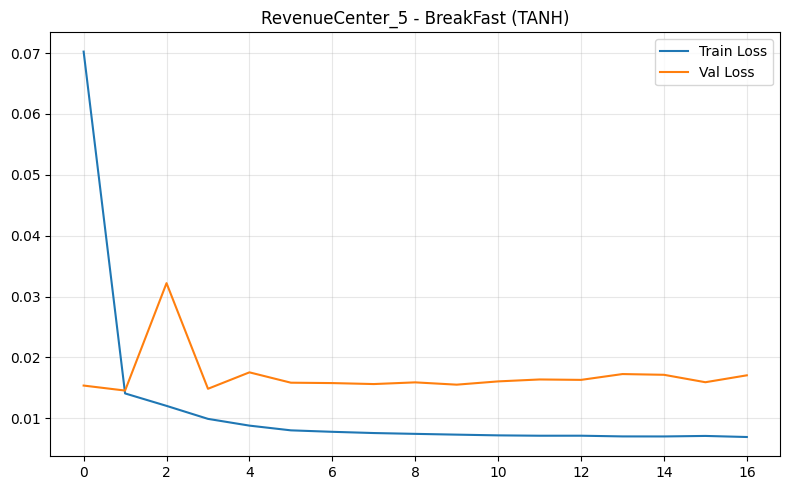

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


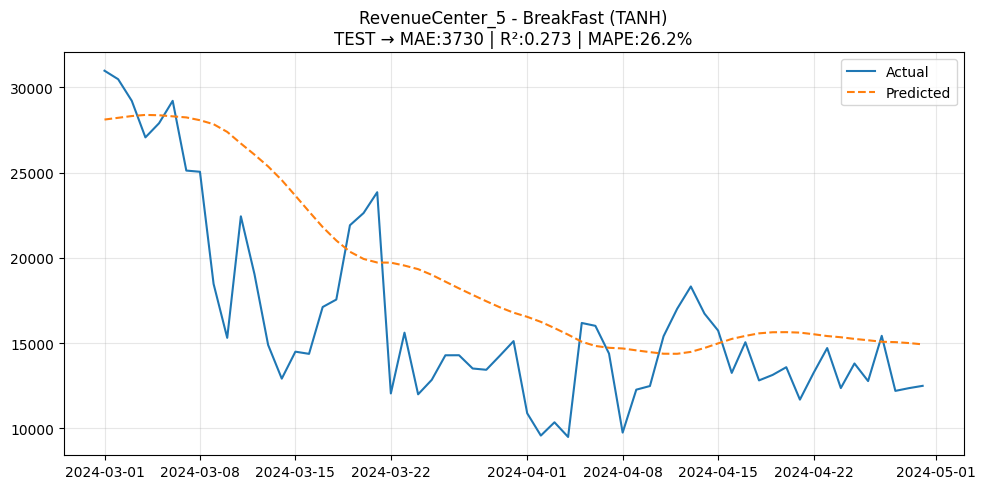

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0180 - val_loss: 0.0204
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0141 - val_loss: 0.0160
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0138 - val_loss: 0.0174
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0132 - val_loss: 0.0160
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0163 - val_loss: 0.0171
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0125 - val_loss: 0.0160
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0138 - val_loss: 0.0161
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0112 - val_loss: 0.0161
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0160 - val_loss: 0.0160
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0131 - val_loss: 0.0164
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0145 - val_loss: 0.0163
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0142 - val_loss: 0.0166
E

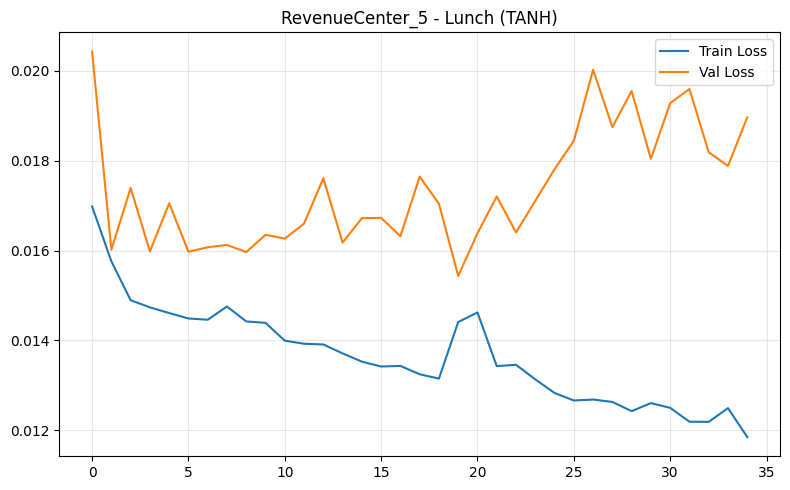

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


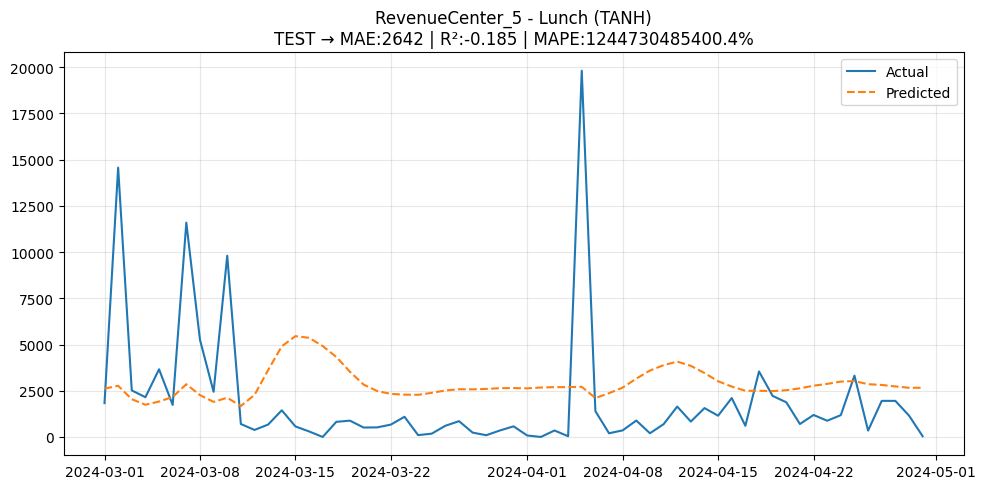

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0325 - val_loss: 0.0629
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0216 - val_loss: 0.0550
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0212 - val_loss: 0.0545
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0200 - val_loss: 0.0569
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0204 - val_loss: 0.0547
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0198 - val_loss: 0.0569
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0168 - val_loss: 0.0562
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0173 - val_loss: 0.0564
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0185 - val_loss: 0.0586
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0187 - val_loss: 0.0582
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0167 - val_loss: 0.0591
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0169 - val_loss: 0.0591


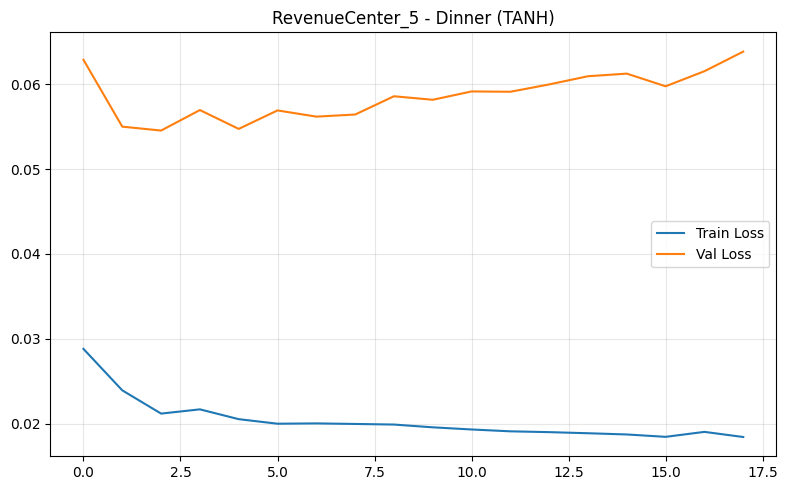

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


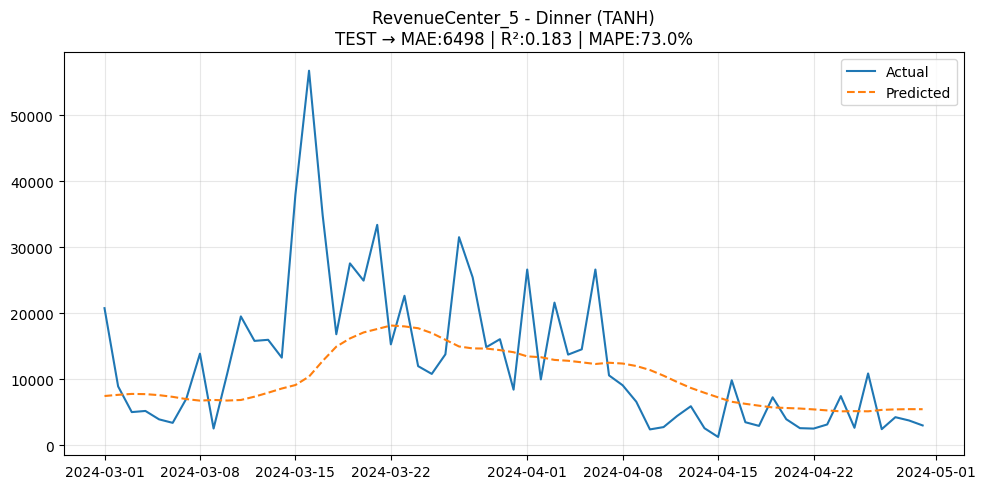

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0109 - val_loss: 0.0050
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0084 - val_loss: 0.0059
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0092 - val_loss: 0.0047
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0093 - val_loss: 0.0046
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0084 - val_loss: 0.0047
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0100 - val_loss: 0.0046
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0106 - val_loss: 0.0047
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0088 - val_loss: 0.0045
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0084 - val_loss: 0.0045
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0096 - val_loss: 0.0046
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0100 - val_loss: 0.0045
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0086 - val_loss: 0.0044
E

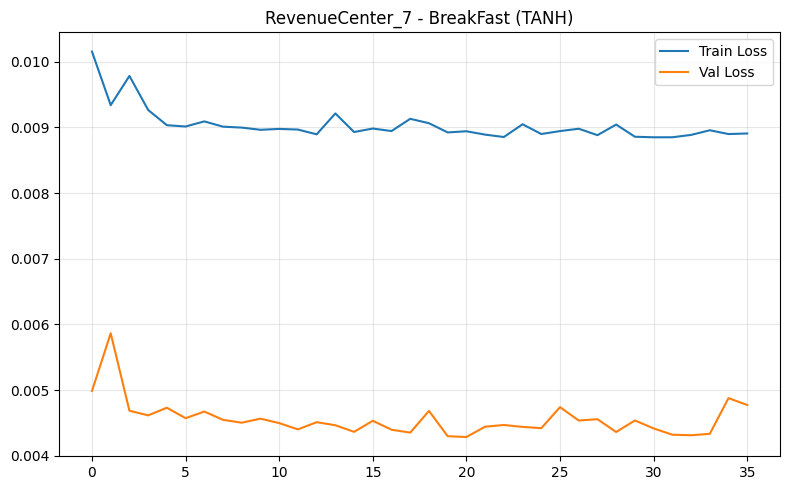

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


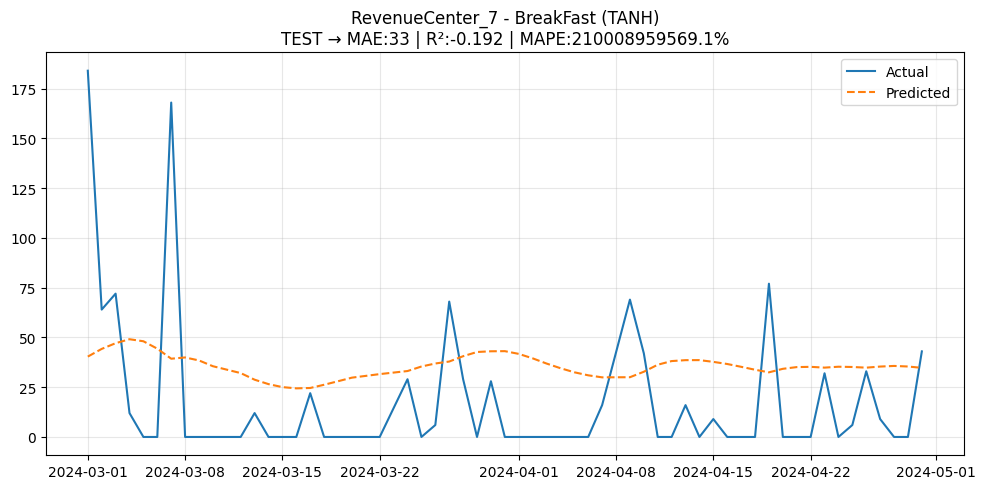

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0140 - val_loss: 0.0426
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0107 - val_loss: 0.0399
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0109 - val_loss: 0.0419
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0109 - val_loss: 0.0403
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0117 - val_loss: 0.0414
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0101 - val_loss: 0.0398
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0111 - val_loss: 0.0403
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0114 - val_loss: 0.0410
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0116 - val_loss: 0.0405
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0109 - val_loss: 0.0396
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0105 - val_loss: 0.0406
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0095 - val_loss: 0.0401
E

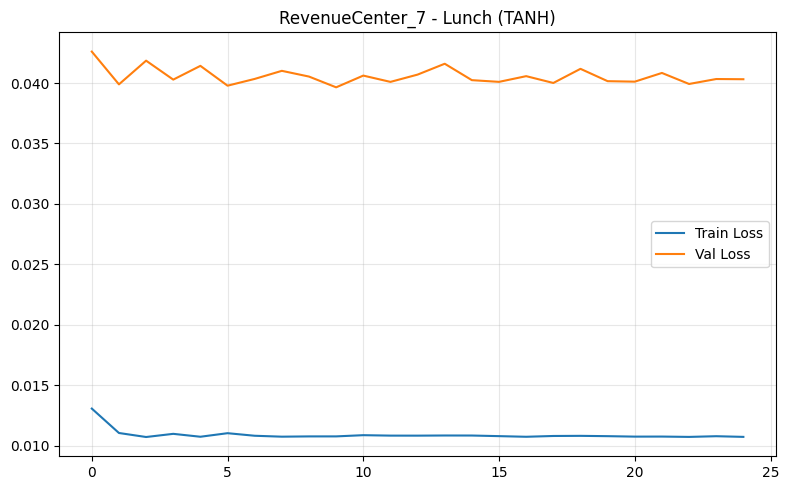

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


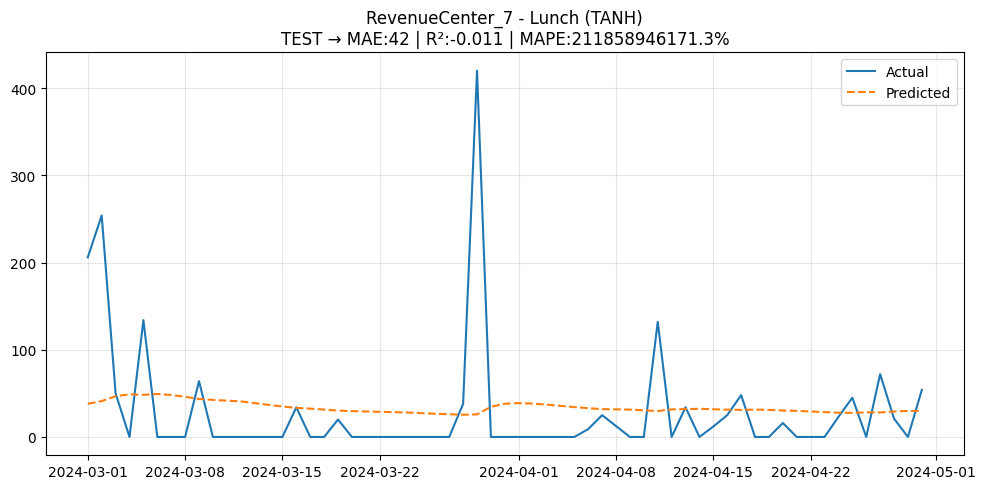

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0277 - val_loss: 0.0907
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0179 - val_loss: 0.0751
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0198 - val_loss: 0.0854
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0201 - val_loss: 0.0812
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0165 - val_loss: 0.0748
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0201 - val_loss: 0.0850
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0193 - val_loss: 0.0916
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0199 - val_loss: 0.0793
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0172 - val_loss: 0.0813
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0187 - val_loss: 0.0800
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0172 - val_loss: 0.0799
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0171 - val_loss: 0.0785


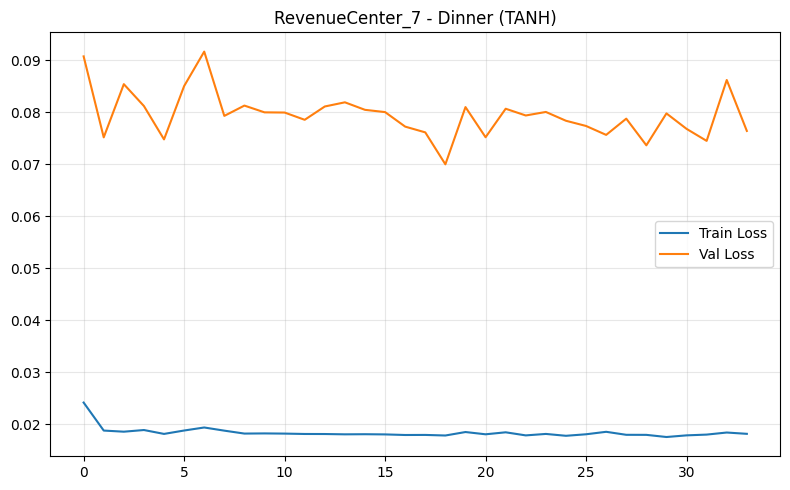

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


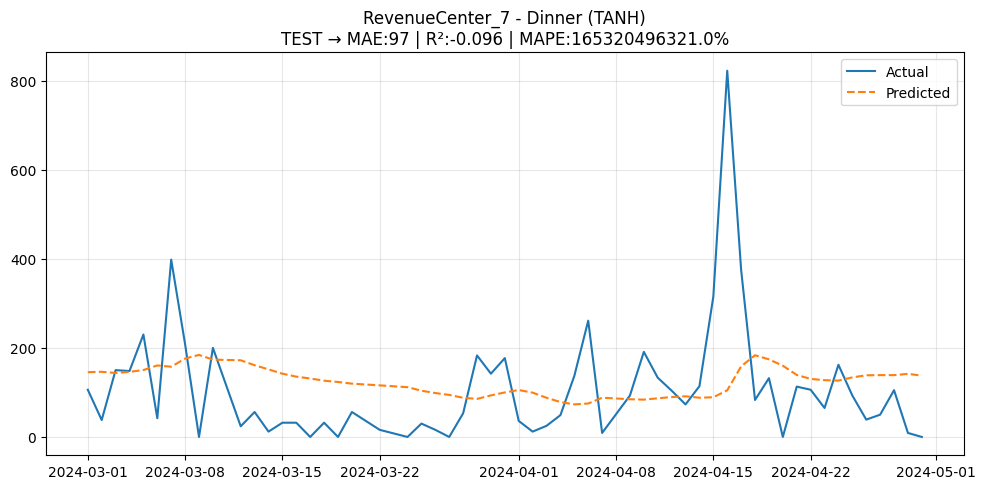

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0247 - val_loss: 0.0310
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0187 - val_loss: 0.0250
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0138 - val_loss: 0.0216
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0158 - val_loss: 0.0253
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0137 - val_loss: 0.0225
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0149 - val_loss: 0.0231
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0171 - val_loss: 0.0257
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0164 - val_loss: 0.0222
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0178 - val_loss: 0.0237
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0179 - val_loss: 0.0253
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0147 - val_loss: 0.0216
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0170 - val_loss: 0.0247


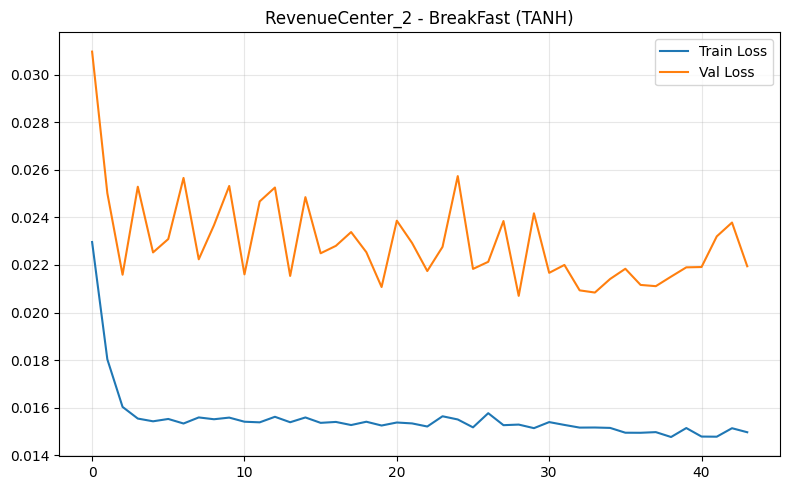

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


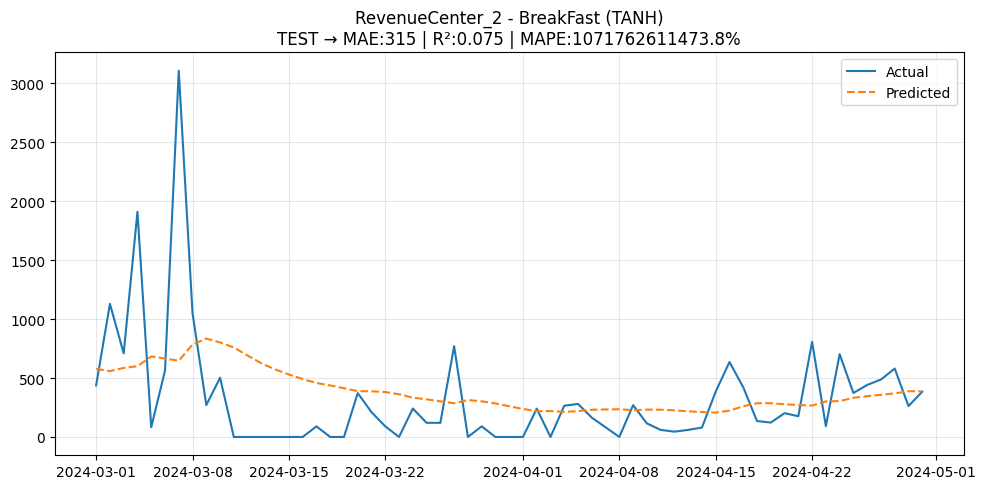

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0303 - val_loss: 0.0543
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0178 - val_loss: 0.0618
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0139 - val_loss: 0.0532
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0192 - val_loss: 0.0633
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0178 - val_loss: 0.0609
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0183 - val_loss: 0.0558
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0171 - val_loss: 0.0637
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0160 - val_loss: 0.0583
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0168 - val_loss: 0.0576
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0174 - val_loss: 0.0596
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0153 - val_loss: 0.0590
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0161 - val_loss: 0.0595


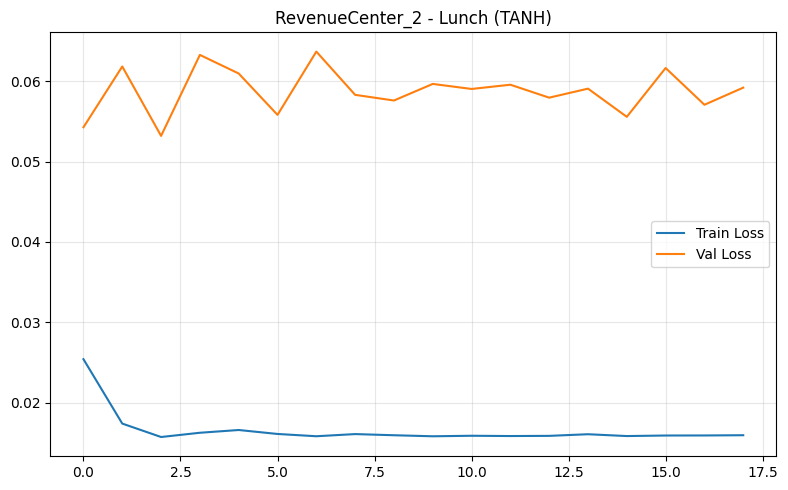

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


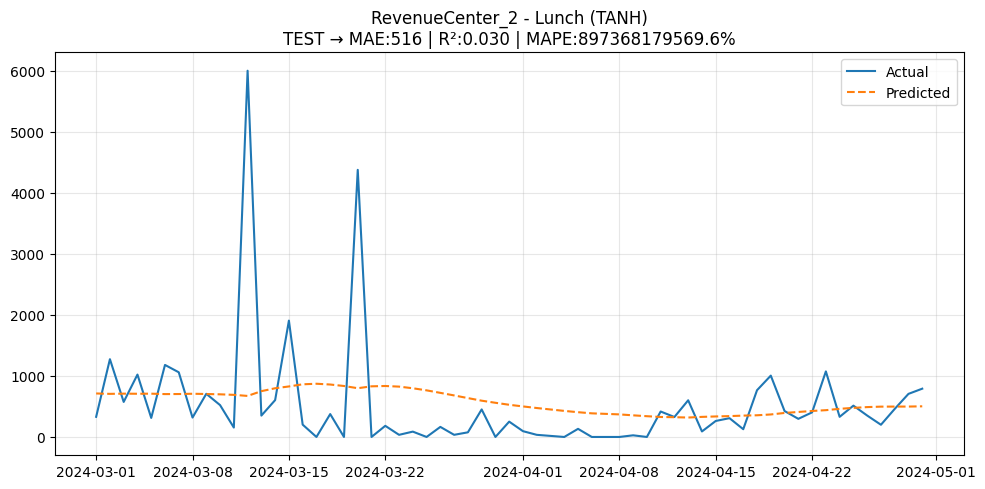

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0025 - val_loss: 0.0287
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0020 - val_loss: 0.0260
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0018 - val_loss: 0.0277
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0020 - val_loss: 0.0266
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0018 - val_loss: 0.0274
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0018 - val_loss: 0.0265
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0016 - val_loss: 0.0271
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0020 - val_loss: 0.0270
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0020 - val_loss: 0.0274
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0025 - val_loss: 0.0267
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0016 - val_loss: 0.0281
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0016 - val_loss: 0.0266
E

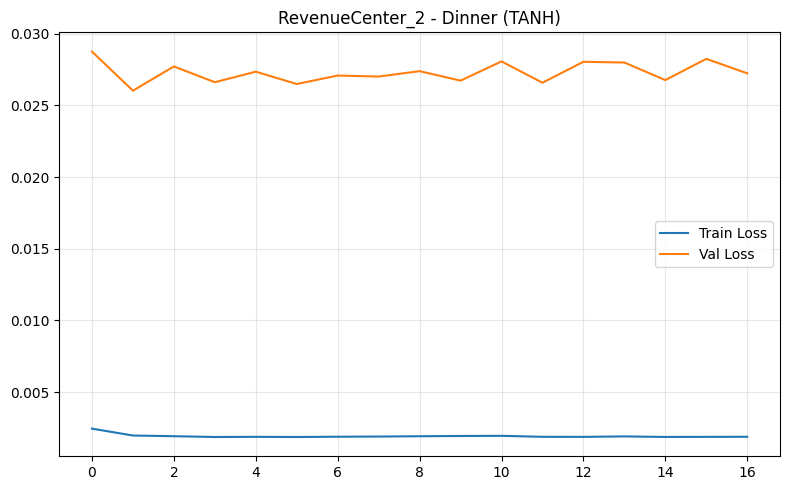

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


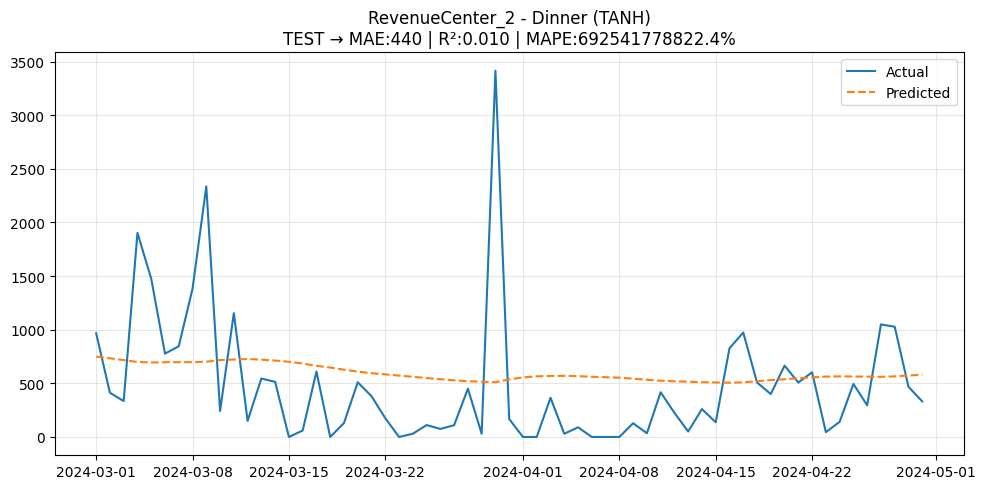

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0086 - val_loss: 0.0348
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0056 - val_loss: 0.0294
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0049 - val_loss: 0.0311
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0045 - val_loss: 0.0283
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0047 - val_loss: 0.0276
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0044 - val_loss: 0.0286
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0047 - val_loss: 0.0287
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0049 - val_loss: 0.0284
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0042 - val_loss: 0.0283
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0042 - val_loss: 0.0288
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0047 - val_loss: 0.0290
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0059 - val_loss: 0.0285
E

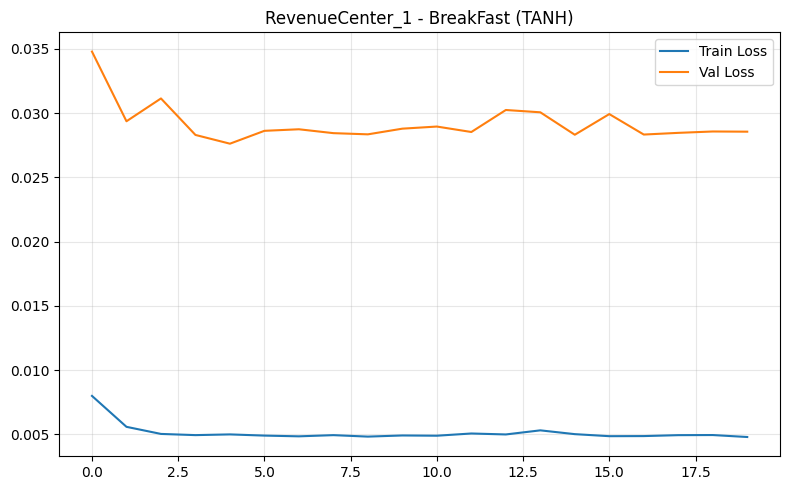

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


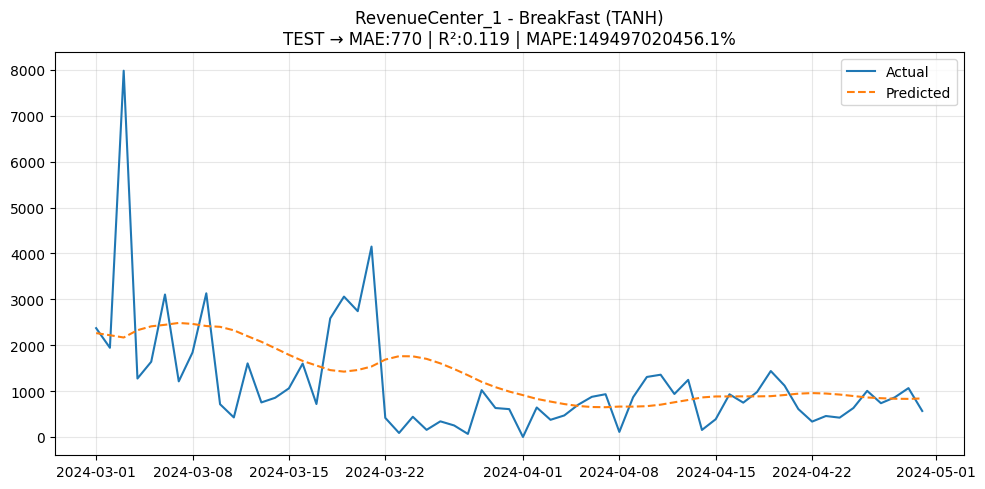

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0242 - val_loss: 0.0707
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0103 - val_loss: 0.0638
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0117 - val_loss: 0.0735
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0142 - val_loss: 0.0724
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0106 - val_loss: 0.0679
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0120 - val_loss: 0.0739
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0106 - val_loss: 0.0659
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0102 - val_loss: 0.0741
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0148 - val_loss: 0.0699
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0120 - val_loss: 0.0708
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0108 - val_loss: 0.0678
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0140 - val_loss: 0.0751


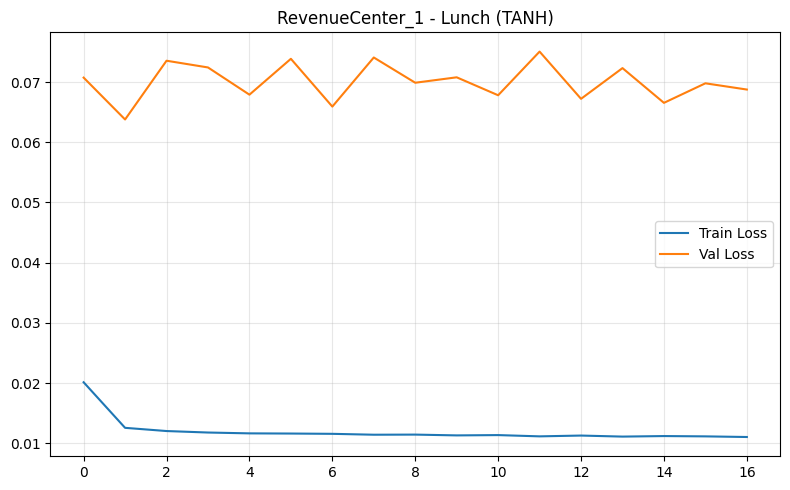

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


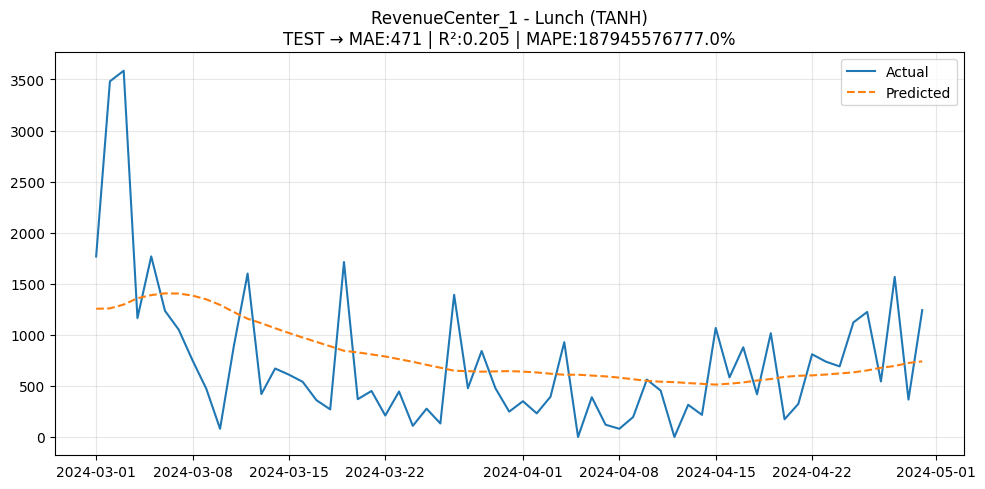

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0509 - val_loss: 0.0328
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0177 - val_loss: 0.0638
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0187 - val_loss: 0.0241
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0162 - val_loss: 0.0409
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0133 - val_loss: 0.0351
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0138 - val_loss: 0.0273
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0117 - val_loss: 0.0375
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0119 - val_loss: 0.0268
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0148 - val_loss: 0.0326
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0130 - val_loss: 0.0295
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0113 - val_loss: 0.0283
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0111 - val_loss: 0.0309
E

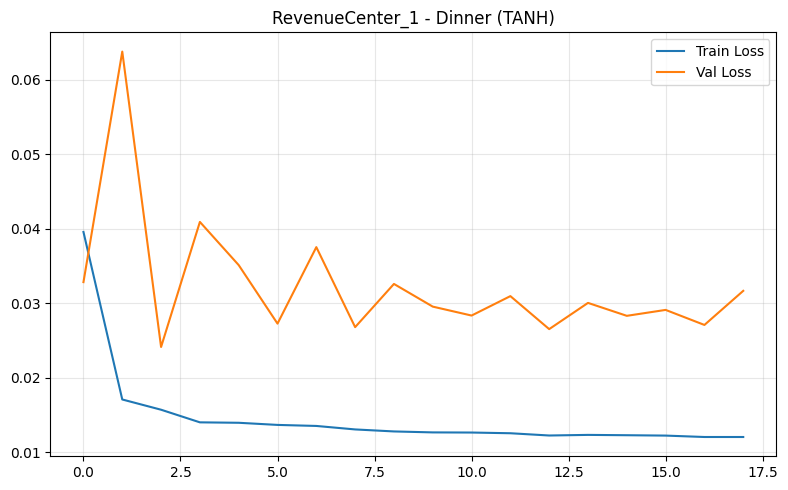

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


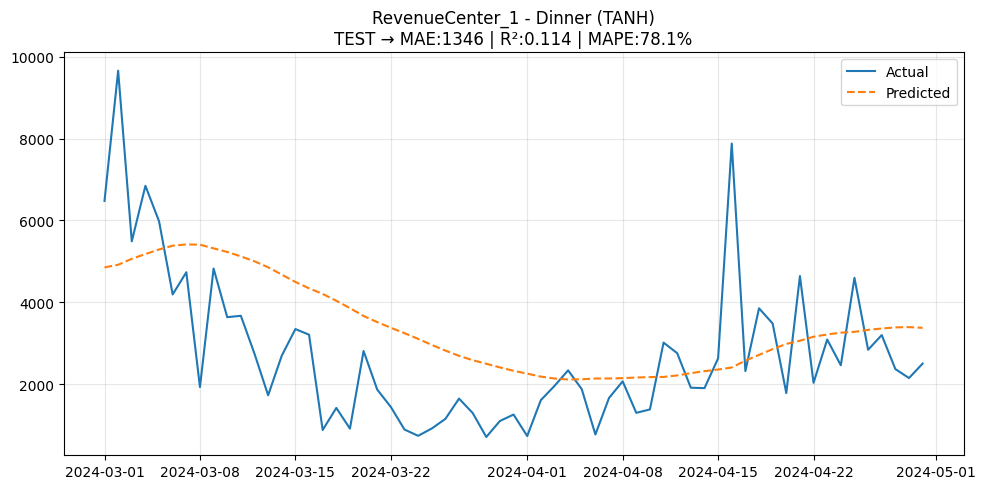

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0244 - val_loss: 0.0506
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0218 - val_loss: 0.0498
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0204 - val_loss: 0.0498
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0231 - val_loss: 0.0499
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0231 - val_loss: 0.0499
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0219 - val_loss: 0.0500
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0243 - val_loss: 0.0503
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0261 - val_loss: 0.0501
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0207 - val_loss: 0.0502
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0228 - val_loss: 0.0505
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0240 - val_loss: 0.0504
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0216 - val_loss: 0.0504
E

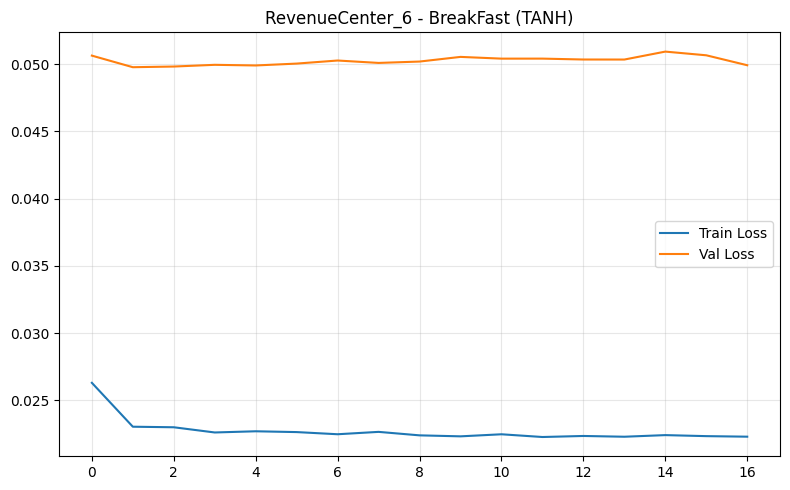

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


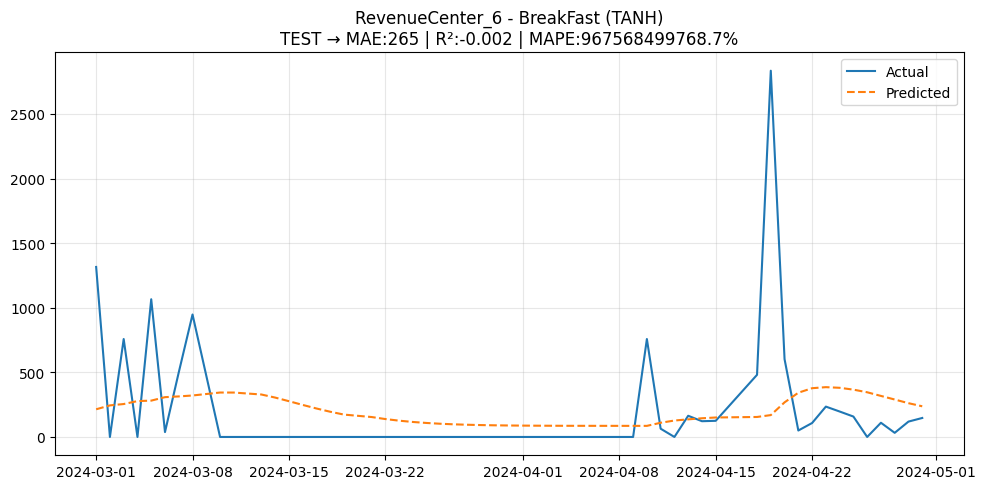

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0142 - val_loss: 0.0183
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0092 - val_loss: 0.0187
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0108 - val_loss: 0.0195
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0117 - val_loss: 0.0194
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0109 - val_loss: 0.0194
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0119 - val_loss: 0.0193
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0100 - val_loss: 0.0197
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0103 - val_loss: 0.0194
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0086 - val_loss: 0.0195
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0087 - val_loss: 0.0192
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0108 - val_loss: 0.0196
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0097 - val_loss: 0.0194
E

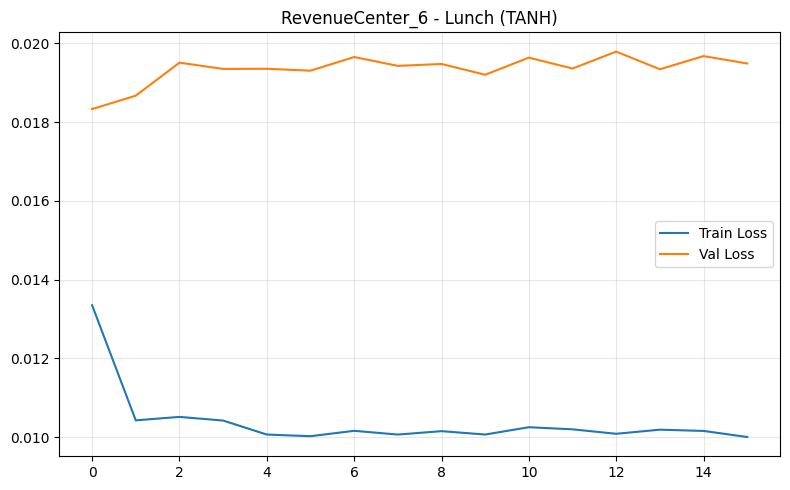

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


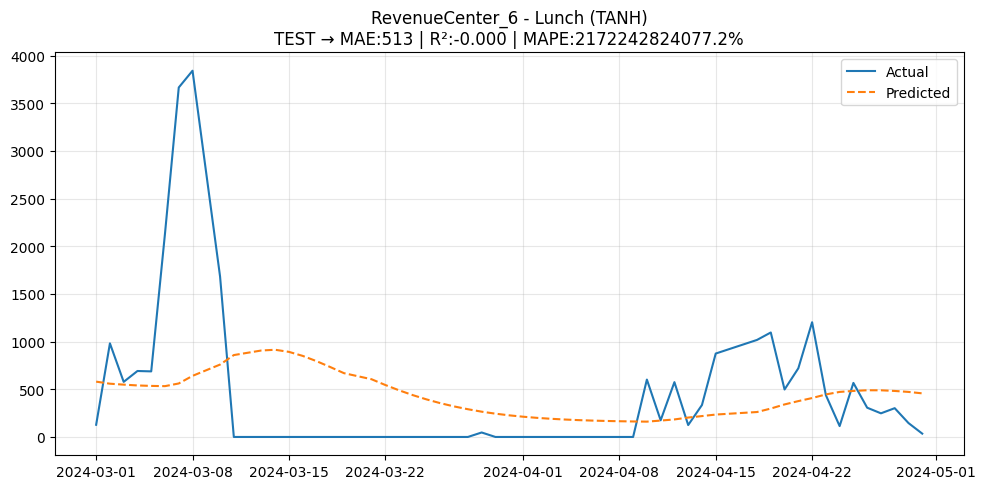

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0040 - val_loss: 0.0250
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0032 - val_loss: 0.0247
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0043 - val_loss: 0.0254
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0024 - val_loss: 0.0245
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0023 - val_loss: 0.0250
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0026 - val_loss: 0.0247
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0035 - val_loss: 0.0252
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0037 - val_loss: 0.0247
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0021 - val_loss: 0.0250
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0033 - val_loss: 0.0248
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0017 - val_loss: 0.0249
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0048 - val_loss: 0.0249
E

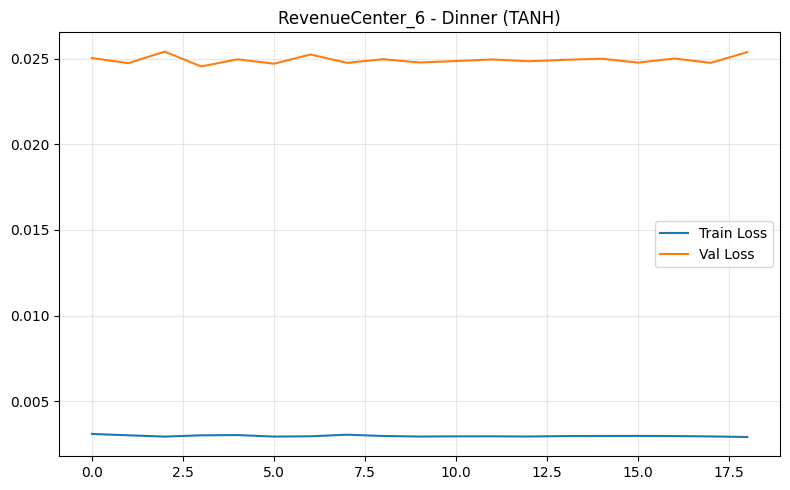

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


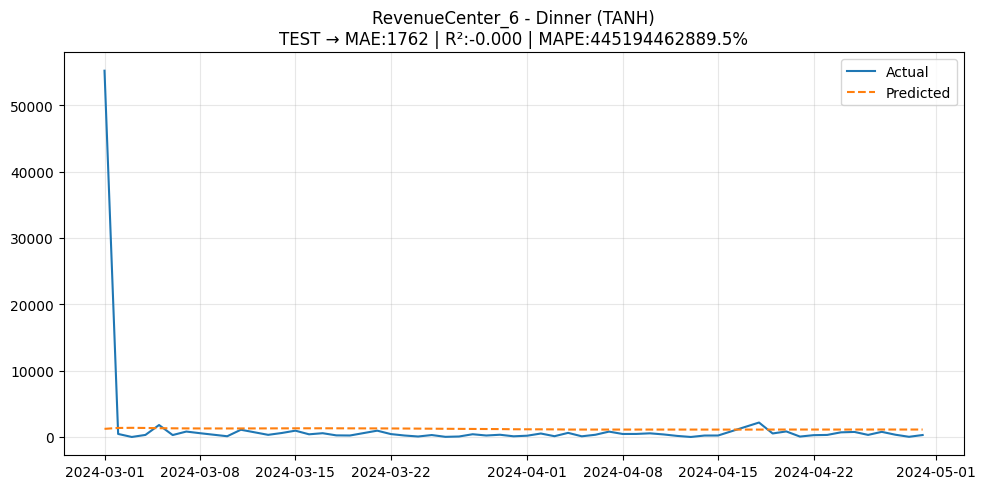

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4
Skipping RevenueCenter_4 - BreakFast (constant values)
Skipping RevenueCenter_4 - Lunch (constant values)
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0059 - val_loss: 1.5079e-06
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0018 - val_loss: 4.2737e-05
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0037 - val_loss: 1.4181e-05
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0037 - val_loss: 5.1020e-05
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0037 - val_loss: 1.8898e-05
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0013 - val_loss: 6.8417e-05
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0026 - val_loss: 2.2874e-05
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0013 - val_loss: 7.7769e-06
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0026 - val_loss: 5.3665e-06
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0026 - val_loss: 4.7678e-06
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0037 - val_loss: 5.7915e-06
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2

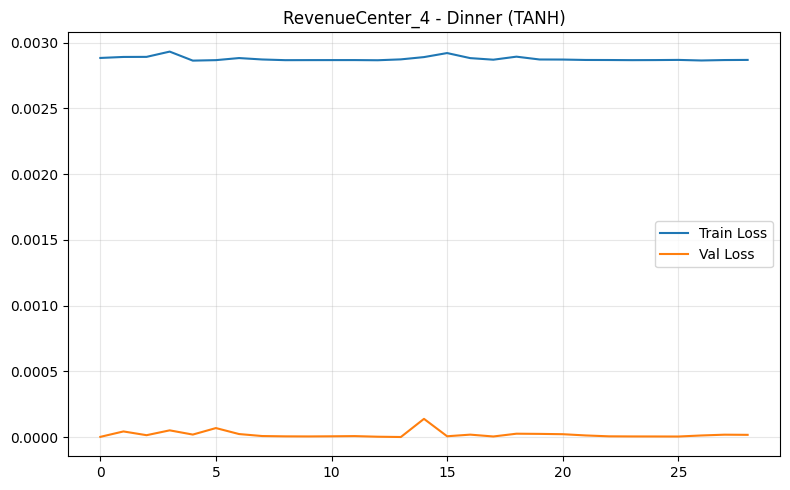

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


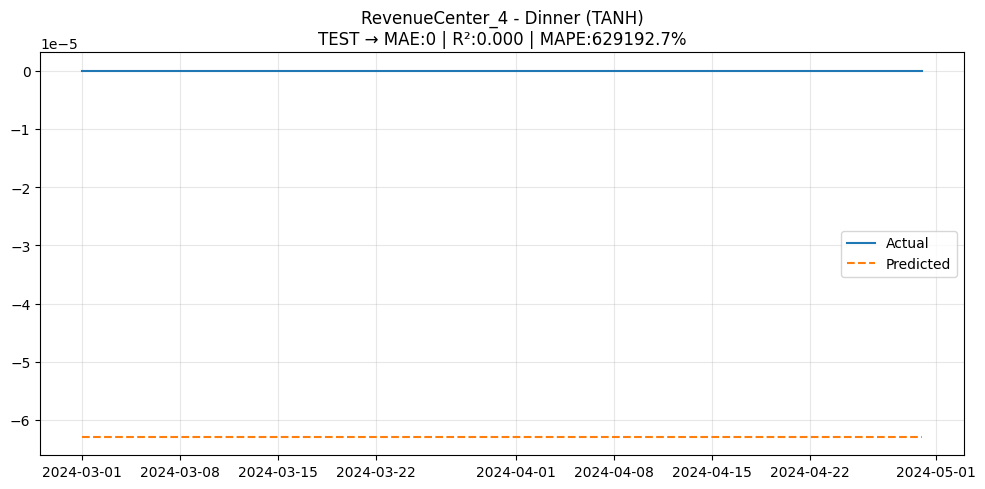

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 0.0092 - val_loss: 0.0023
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0120 - val_loss: 0.0023
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0118 - val_loss: 0.0023
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0057 - val_loss: 0.0025
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0067 - val_loss: 0.0026
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0058 - val_loss: 0.0023
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0080 - val_loss: 0.0025
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0078 - val_loss: 0.0024
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0077 - val_loss: 0.0024
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0120 - val_loss: 0.0024
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0072 - val_loss: 0.0023
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0067 - val_loss: 0.0025


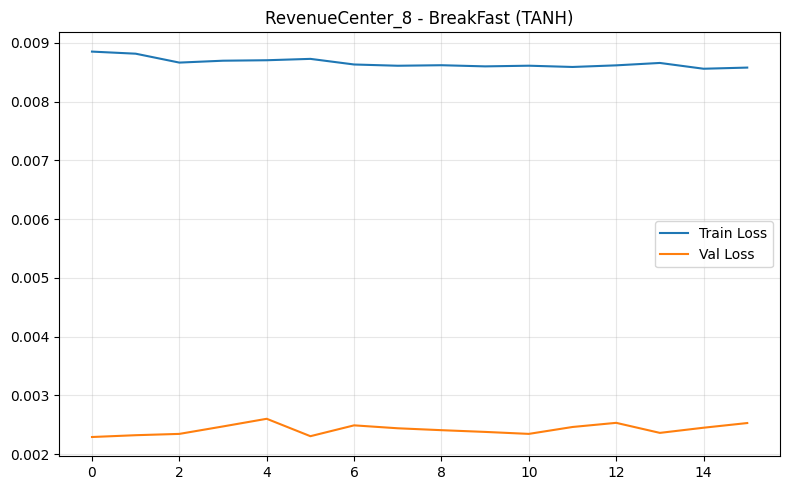

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


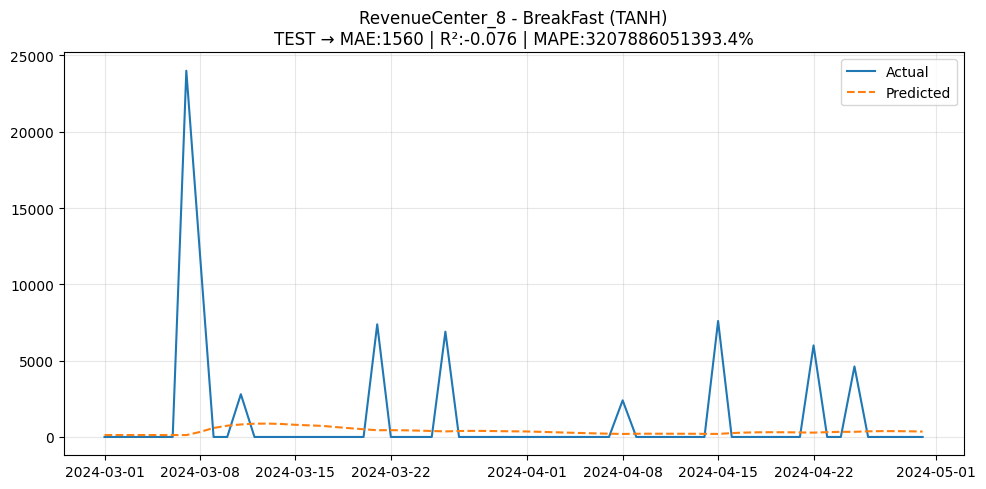

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0154 - val_loss: 0.1013
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0155 - val_loss: 0.0985
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0139 - val_loss: 0.1036
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0160 - val_loss: 0.1031
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0146 - val_loss: 0.0987
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0159 - val_loss: 0.1012
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0147 - val_loss: 0.1011
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0157 - val_loss: 0.0972
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0145 - val_loss: 0.1012
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0130 - val_loss: 0.1003
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0154 - val_loss: 0.1002
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0133 - val_loss: 0.1033
E

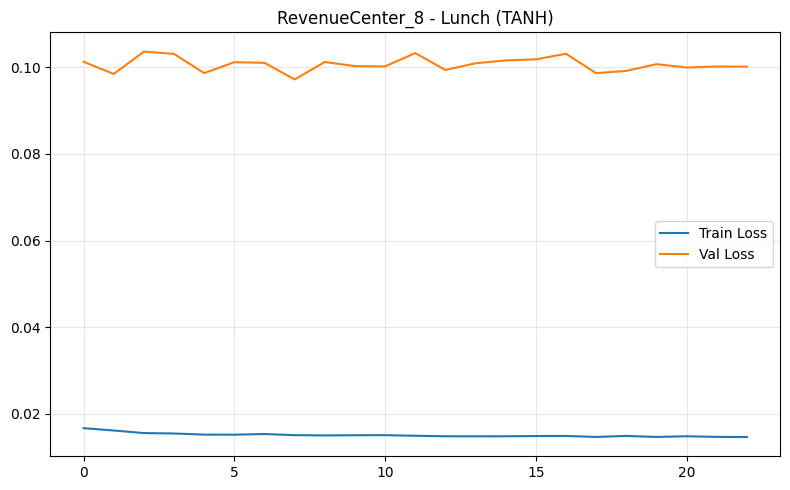

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


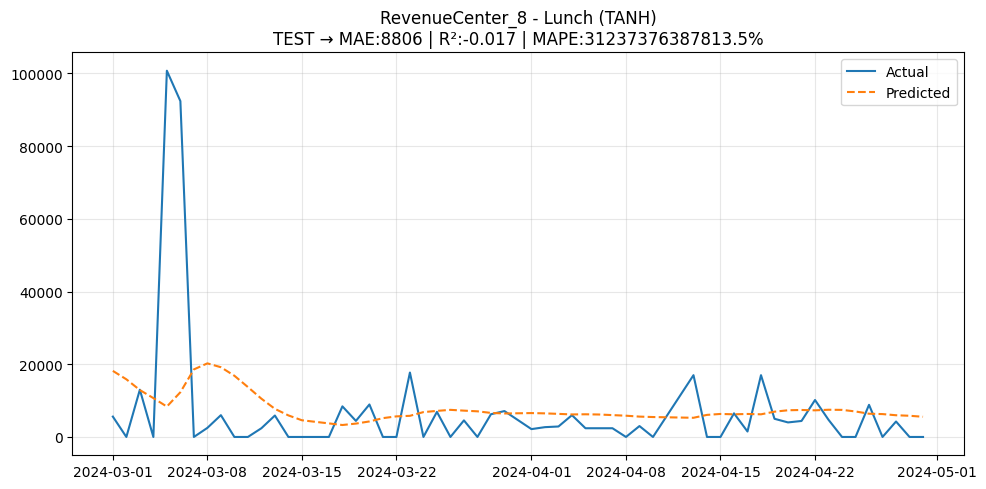

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0153 - val_loss: 0.0567
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0130 - val_loss: 0.0515
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0154 - val_loss: 0.0552
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0143 - val_loss: 0.0592
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0120 - val_loss: 0.0524
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0132 - val_loss: 0.0538
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0147 - val_loss: 0.0570
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0132 - val_loss: 0.0549
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0146 - val_loss: 0.0530
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0137 - val_loss: 0.0554
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0134 - val_loss: 0.0543
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0134 - val_loss: 0.0534
E

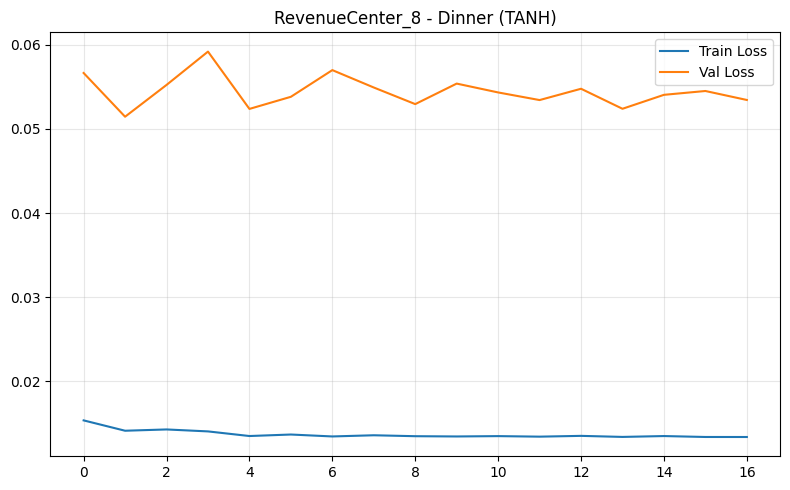

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


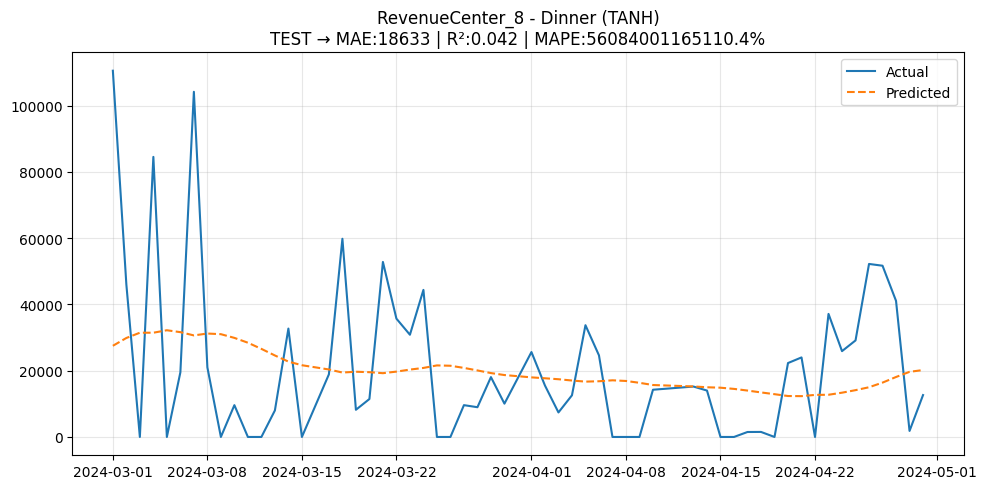

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0277 - val_loss: 0.0378
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0241 - val_loss: 0.0362
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0195 - val_loss: 0.0364
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0219 - val_loss: 0.0366
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0255 - val_loss: 0.0383
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0252 - val_loss: 0.0386
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0237 - val_loss: 0.0366
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0210 - val_loss: 0.0381
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0211 - val_loss: 0.0372
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0240 - val_loss: 0.0377
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0212 - val_loss: 0.0394
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0247 - val_loss: 0.0364
E

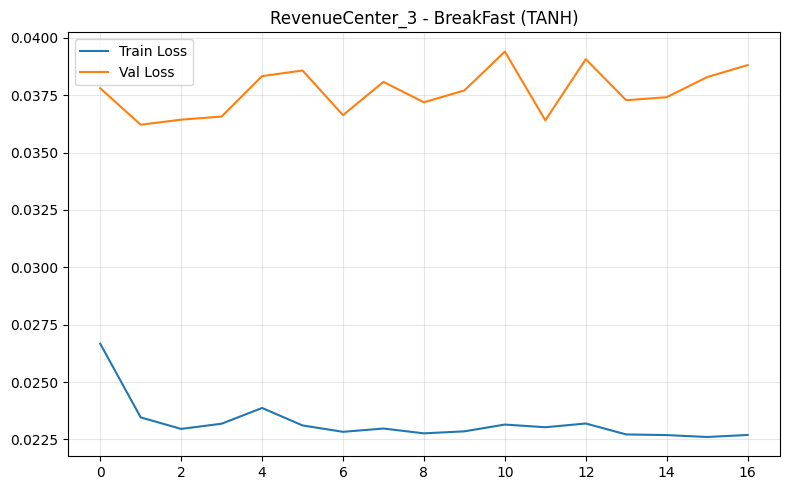

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


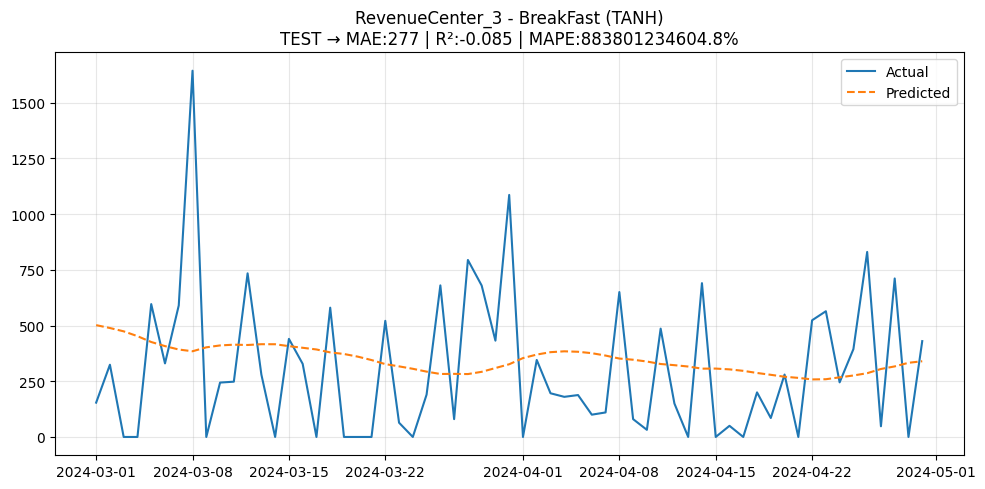

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0274 - val_loss: 0.0435
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0112 - val_loss: 0.0647
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0104 - val_loss: 0.0461
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0098 - val_loss: 0.0586
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0113 - val_loss: 0.0540
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0107 - val_loss: 0.0522
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0104 - val_loss: 0.0539
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0093 - val_loss: 0.0560
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0101 - val_loss: 0.0530
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0090 - val_loss: 0.0546
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0094 - val_loss: 0.0532
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0084 - val_loss: 0.0562
E

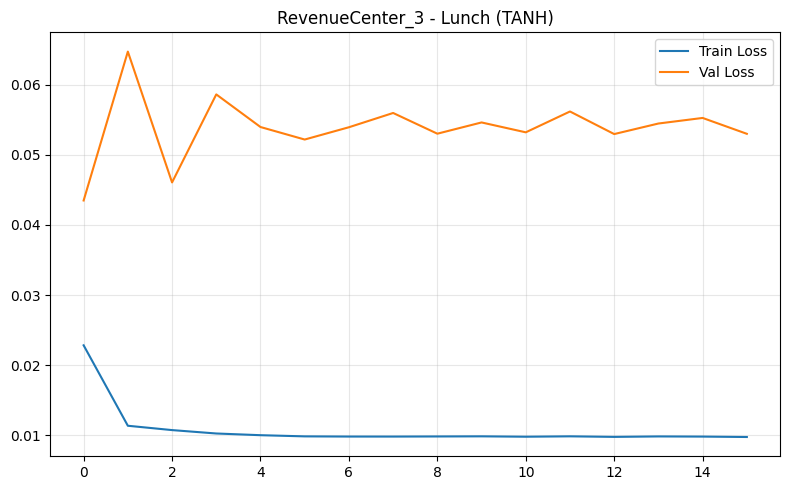

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


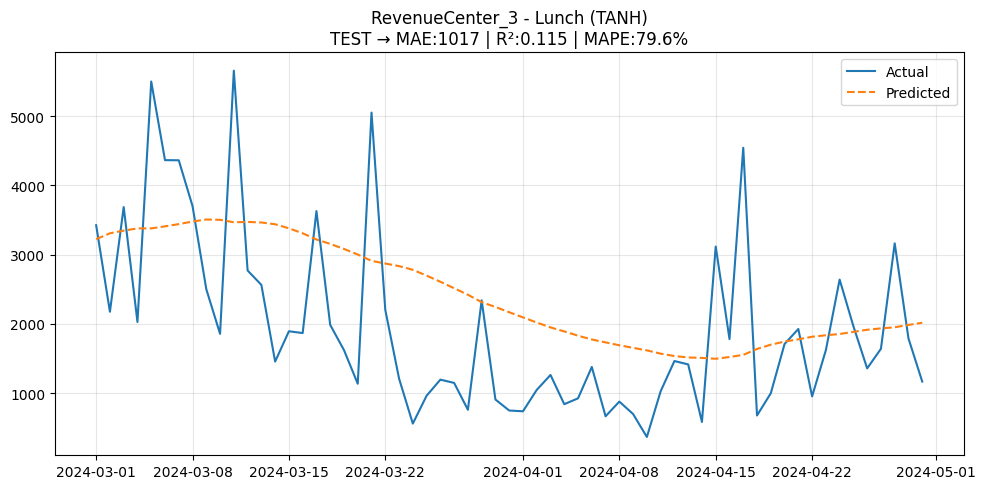

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0367 - val_loss: 0.0815
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0137 - val_loss: 0.0561
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0108 - val_loss: 0.0431
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0111 - val_loss: 0.0649
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0107 - val_loss: 0.0403
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0109 - val_loss: 0.0542
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0114 - val_loss: 0.0437
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0093 - val_loss: 0.0430
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0103 - val_loss: 0.0385
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0105 - val_loss: 0.0387
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0095 - val_loss: 0.0373
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0106 - val_loss: 0.0337
E

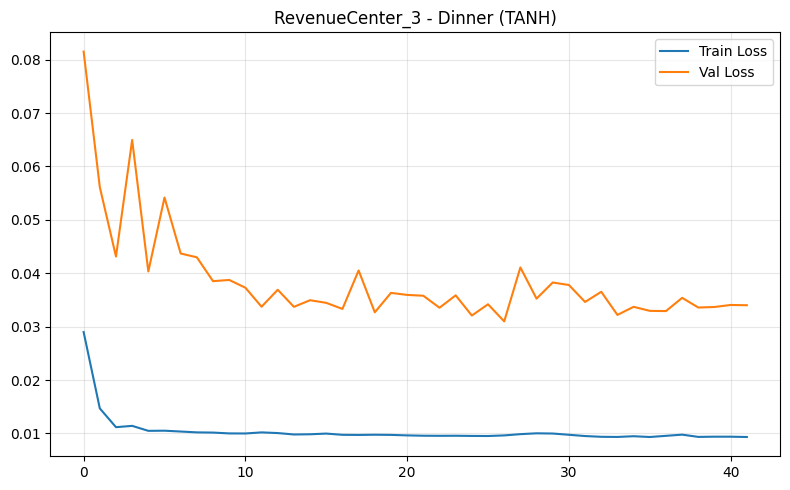

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


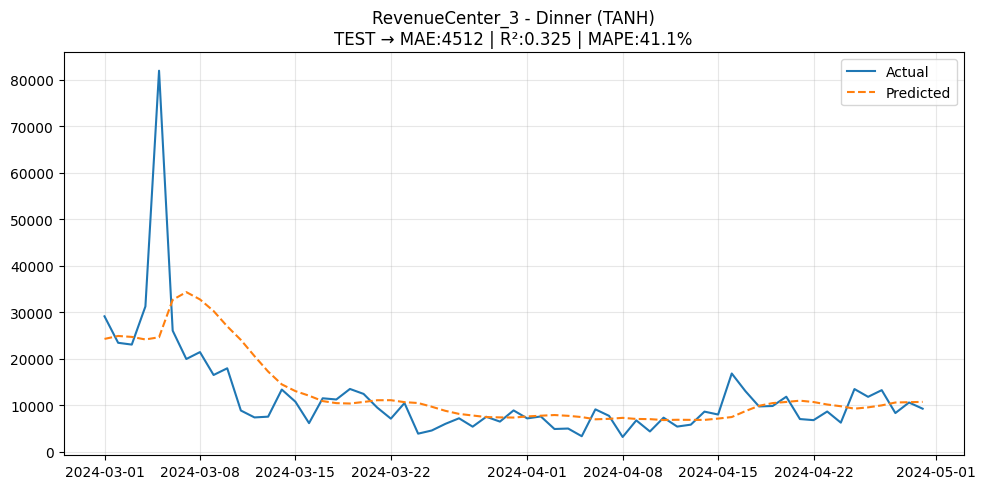

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0116 - val_loss: 0.0681
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0100 - val_loss: 0.0746
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0090 - val_loss: 0.0677
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0099 - val_loss: 0.0740
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0095 - val_loss: 0.0686
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0090 - val_loss: 0.0661
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0087 - val_loss: 0.0673
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0097 - val_loss: 0.0697
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0099 - val_loss: 0.0704
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0098 - val_loss: 0.0755
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0071 - val_loss: 0.0719
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0098 - val_loss: 0.0694


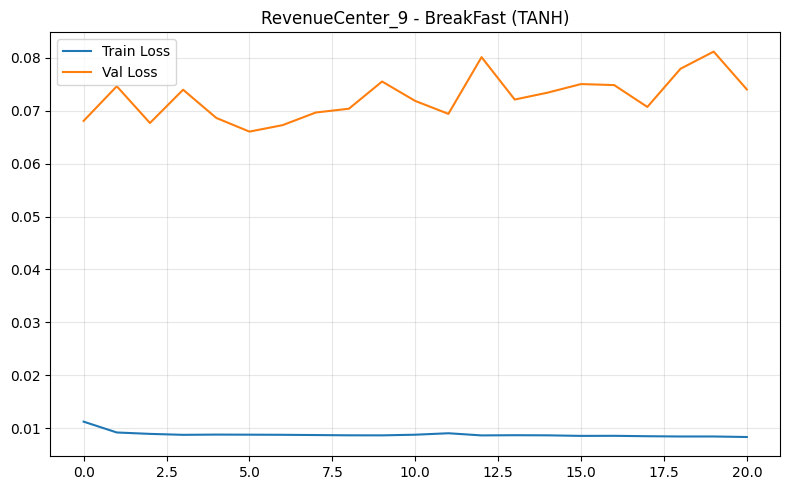

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


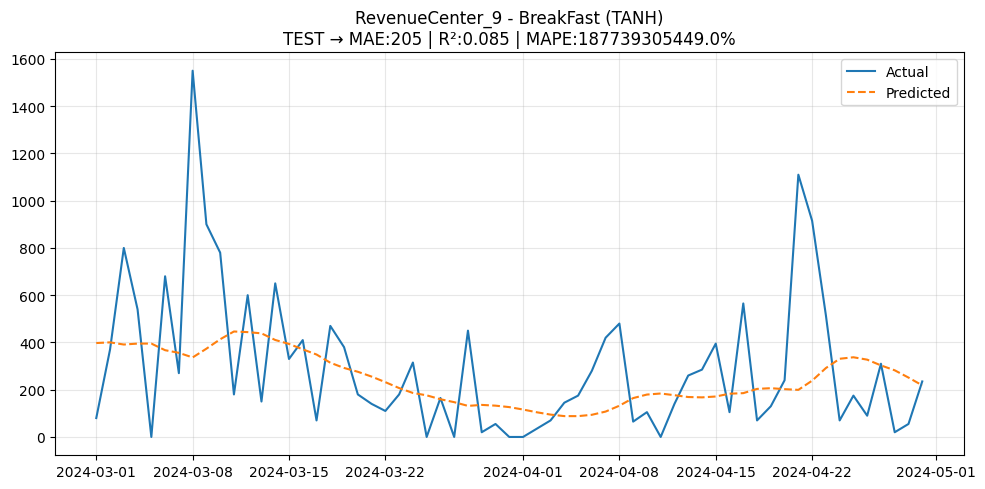

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0406 - val_loss: 0.0497
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0331 - val_loss: 0.0532
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0257 - val_loss: 0.0474
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0278 - val_loss: 0.0483
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0340 - val_loss: 0.0480
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0311 - val_loss: 0.0476
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0302 - val_loss: 0.0489
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0336 - val_loss: 0.0471
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0289 - val_loss: 0.0476
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0294 - val_loss: 0.0473
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0303 - val_loss: 0.0483
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0285 - val_loss: 0.0473
E

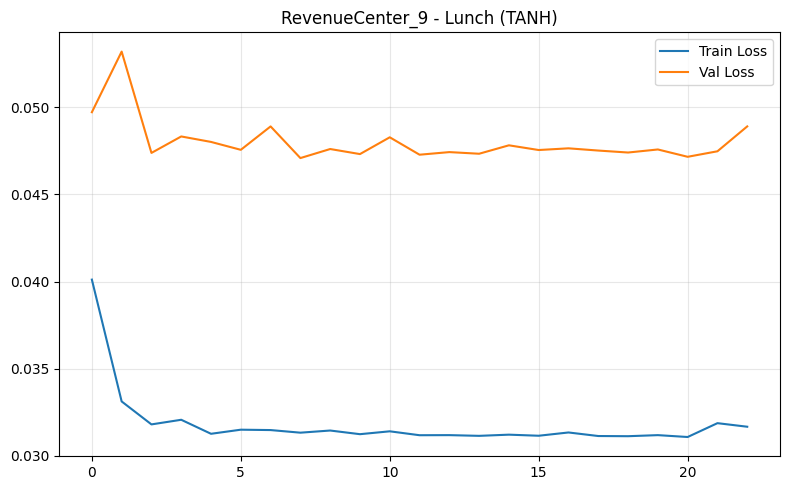

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


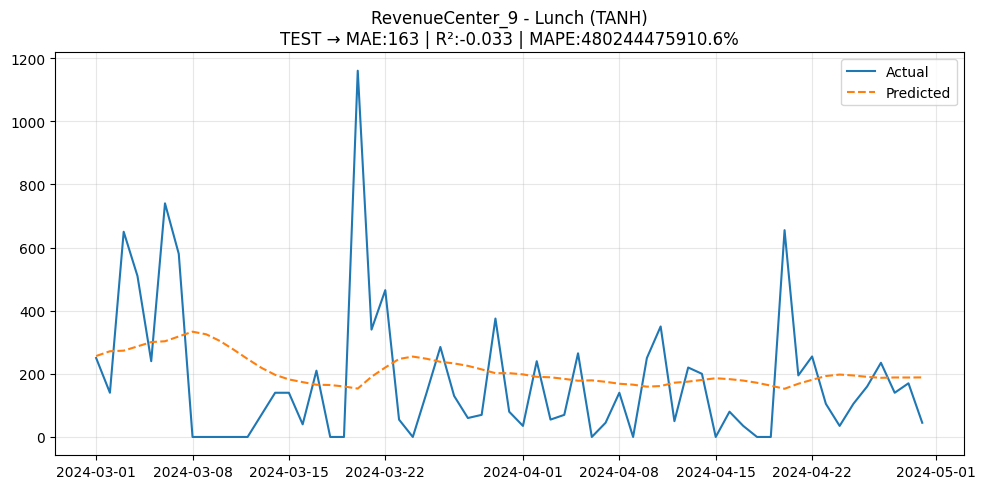

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.0245 - val_loss: 0.0135
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0294 - val_loss: 0.0135
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0215 - val_loss: 0.0140
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0234 - val_loss: 0.0143
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0180 - val_loss: 0.0135
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0246 - val_loss: 0.0146
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0258 - val_loss: 0.0139
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0239 - val_loss: 0.0137
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0207 - val_loss: 0.0141
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0253 - val_loss: 0.0144
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0220 - val_loss: 0.0139
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0219 - val_loss: 0.0142


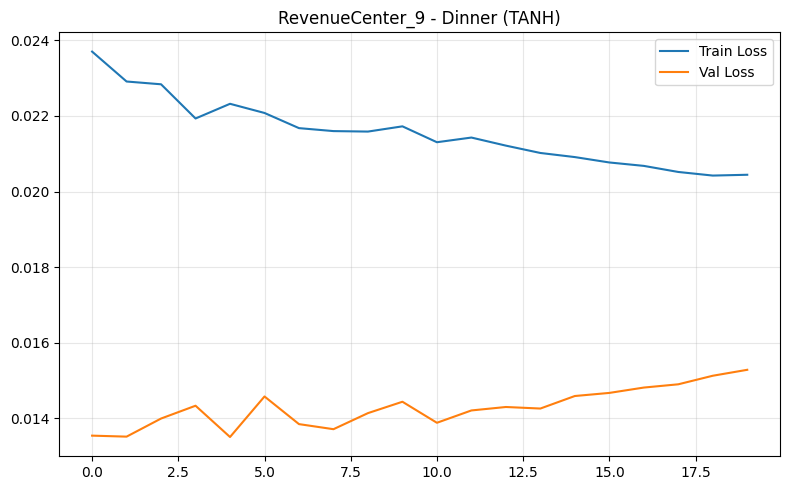

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


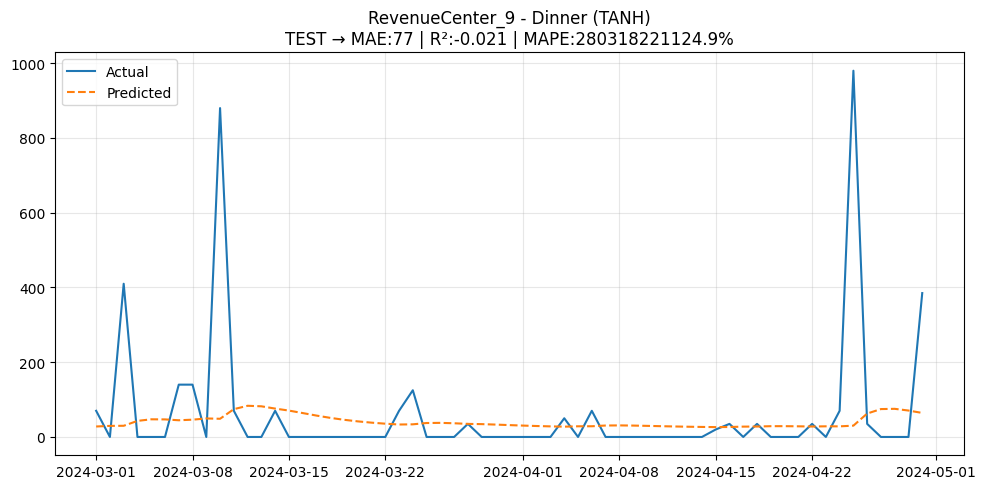

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — TANH MODEL


In [18]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            print(f"Skipping {center_name} - {meal} (constant values)")
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — TANH
        # =========================
        model = Sequential([

            LSTM(
                256,
                activation="tanh",
                return_sequences=True,
                input_shape=(WINDOW, 1)
            ),

            LSTM(
                128,
                activation="tanh",
                return_sequences=False
            ),

            Dense(32, activation="relu"),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=64,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (TANH)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_tanh.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (TANH)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — TANH MODEL")

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
